# BÁO CÁO THỰC NGHIỆM: N-GRAM LANGUAGE MODELS, SMOOTHING & PERPLEXITY (LAB 02)

**Học phần:** Xử lý ngôn ngữ tự nhiên và ứng dụng (NLP 2026)  
**Tập dữ liệu:** Ngữ liệu C4 (`c4-train.00000-of-01024-30K.json` gồm 30.000 văn bản tiếng Anh)  

---


## 13. Experiment 1 — Phân tích thống kê ngữ liệu (Corpus Statistics)

Trong thực nghiệm mở đầu, ta khảo sát các thuộc tính thống kê cấu trúc của tập ngữ liệu C4: số văn bản, số câu, tổng số token, độ lớn từ vựng ($|\mathcal{V}|$) và sự bùng nổ không gian trạng thái khi tăng bậc $n$ ($n \in \{1, 2, 3\}$).


In [1]:
import re
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. Đọc toàn bộ 30.000 văn bản C4
data_path = "../Lab1/c4-train.00000-of-01024-30K.json"
df = pd.read_json(data_path, lines=True)

print(f"Tổng số văn bản (Documents): {len(df):,}")
df.head()


Tổng số văn bản (Documents): 30,000


,text,timestamp,url
0,Beginners BBQ Class Taking Place in Missoula!\...,2019-04-25 12:57:54+00:00,https://klyq.com/beginners-bbq-class-taking-pl...
1,Discussion in 'Mac OS X Lion (10.7)' started b...,2019-04-21 10:07:13+00:00,https://forums.macrumors.com/threads/restore-f...
2,Foil plaid lycra and spandex shortall with met...,2019-04-25 10:40:23+00:00,https://awishcometrue.com/Catalogs/Clearance/T...
3,How many backlinks per day for new site?\nDisc...,2019-04-21 12:46:19+00:00,https://www.blackhatworld.com/seo/how-many-bac...
4,The Denver Board of Education opened the 2017-...,2019-04-20 14:33:21+00:00,http://bond.dpsk12.org/category/news/


In [2]:
num_documents = len(df)

# 2. Tách câu bằng biểu thức chính quy
sentences = []
for doc in df["text"]:
    sents = [s.strip() for s in re.split(r"[\n.!?]+", str(doc)) if s.strip()]
    sentences.extend(sents)

num_sentences = len(sentences)
print(f"Tổng số câu trích xuất: {num_sentences:,}")


Tổng số câu trích xuất: 691,345


In [3]:
# 3. Tokenize toàn bộ các câu và thống kê token
tokenized_sentences = []
total_tokens = 0

for sent in sentences:
    tokens = re.findall(r"[a-zA-Z0-9]+", sent.lower())
    if tokens:
        tokenized_sentences.append(tokens)
        total_tokens += len(tokens)

print(f"Tổng số token: {total_tokens:,}")


Tổng số token: 11,093,241


In [4]:
# 4. Thống kê Unigram, Bigram, Trigram và Singletons
unigrams = Counter()
for tokens in tokenized_sentences:
    unigrams.update(tokens)

vocab_size = len(unigrams)
num_unigrams = vocab_size

bigrams = Counter()
for tokens in tokenized_sentences:
    if len(tokens) >= 2:
        bigrams.update(zip(tokens[:-1], tokens[1:]))
num_bigrams = len(bigrams)

trigrams = Counter()
for tokens in tokenized_sentences:
    if len(tokens) >= 3:
        trigrams.update(zip(tokens[:-2], tokens[1:-1], tokens[2:]))
num_trigrams = len(trigrams)

single_unigrams = sum(1 for c in unigrams.values() if c == 1)
single_bigrams = sum(1 for c in bigrams.values() if c == 1)
single_trigrams = sum(1 for c in trigrams.values() if c == 1)

summary_df = pd.DataFrame({
    "Model": ["Unigram", "Bigram", "Trigram"],
    "# unique n-grams": [num_unigrams, num_bigrams, num_trigrams],
    "# singletons": [single_unigrams, single_bigrams, single_trigrams],
    "% singletons": [
        f"{single_unigrams / vocab_size * 100:.2f}%",
        f"{single_bigrams / num_bigrams * 100:.2f}%",
        f"{single_trigrams / num_trigrams * 100:.2f}%"
    ]
})

print("=== BẢNG TỔNG HỢP THỐNG KÊ N-GRAM TRÊN 30K DOCUMENTS ===")
summary_df


=== BẢNG TỔNG HỢP THỐNG KÊ N-GRAM TRÊN 30K DOCUMENTS ===


,Model,# unique n-grams,# singletons,% singletons
0,Unigram,186618,88482,47.41%
1,Bigram,2739018,1953031,71.30%
2,Trigram,6404589,5521625,86.21%


### Trực quan hóa phân phối tần suất Zipf và Top 15 N-grams phổ biến nhất


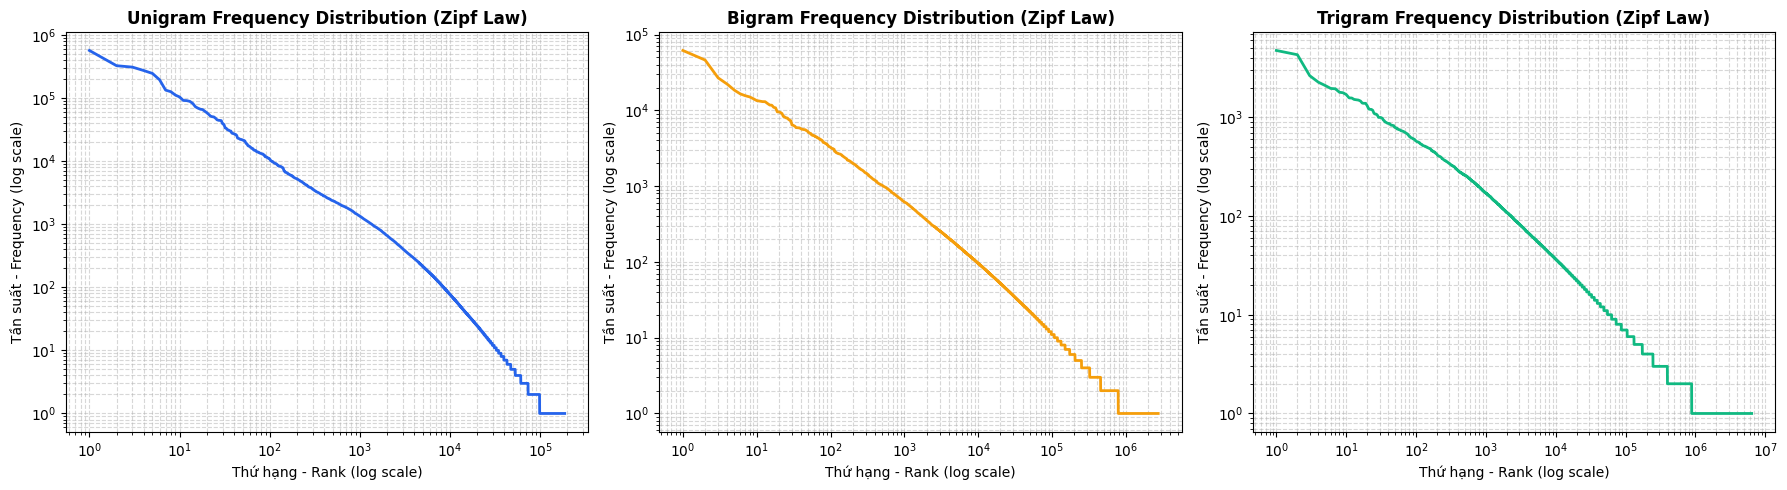

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data = [
    ("Unigram", unigrams, "#2563eb"),
    ("Bigram", bigrams, "#f59e0b"),
    ("Trigram", trigrams, "#10b981")
]

for ax, (title, counter, color) in zip(axes, data):
    counts = sorted(counter.values(), reverse=True)
    ranks = np.arange(1, len(counts) + 1)
    ax.loglog(ranks, counts, color=color, linewidth=2)
    ax.set_title(f"{title} Frequency Distribution (Zipf Law)", fontweight="bold")
    ax.set_xlabel("Thứ hạng - Rank (log scale)")
    ax.set_ylabel("Tần suất - Frequency (log scale)")
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


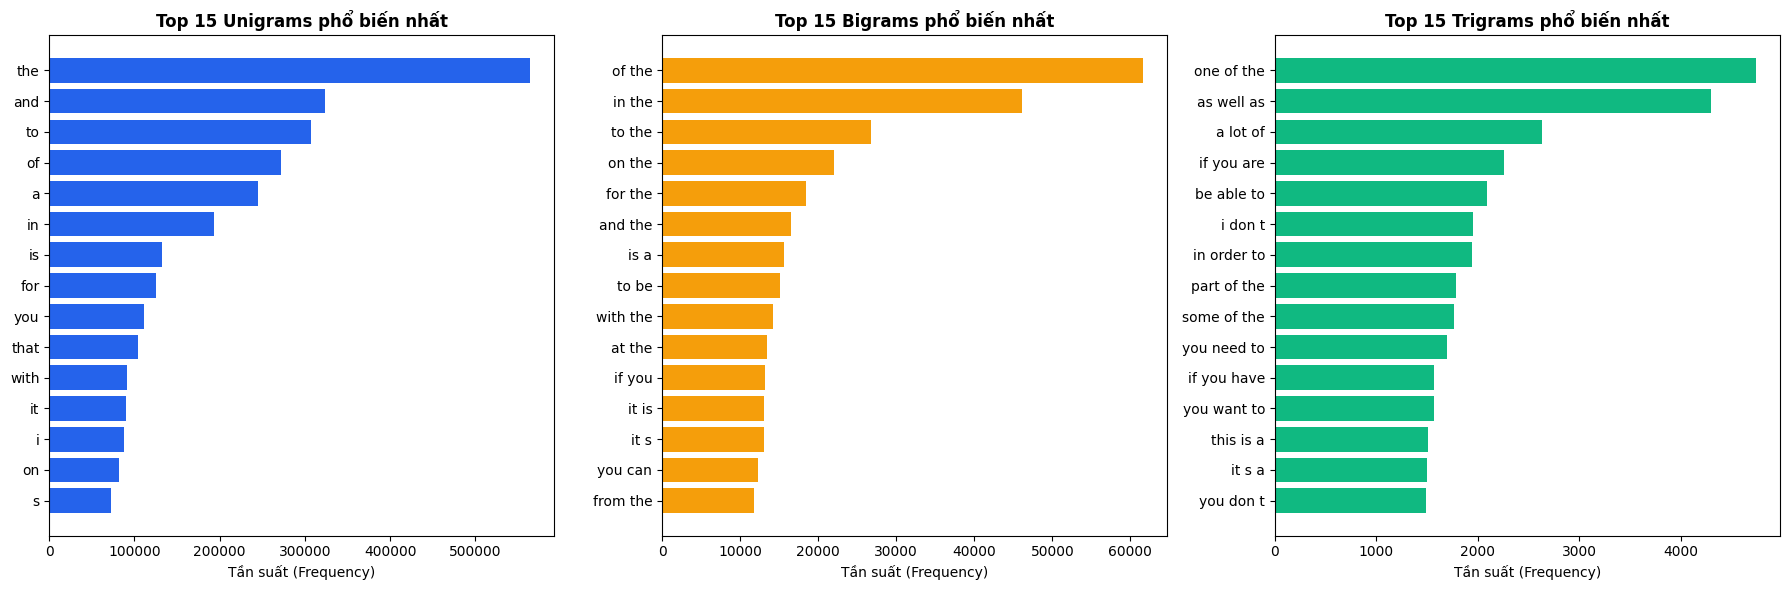

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_uni = unigrams.most_common(15)
words_uni, counts_uni = zip(*top_uni)
axes[0].barh(range(len(words_uni)), counts_uni, color="#2563eb")
axes[0].set_yticks(range(len(words_uni)))
axes[0].set_yticklabels(words_uni)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Unigrams phổ biến nhất", fontweight="bold")
axes[0].set_xlabel("Tần suất (Frequency)")

top_bi = bigrams.most_common(15)
words_bi = [" ".join(pair) for pair, _ in top_bi]
counts_bi = [c for _, c in top_bi]
axes[1].barh(range(len(words_bi)), counts_bi, color="#f59e0b")
axes[1].set_yticks(range(len(words_bi)))
axes[1].set_yticklabels(words_bi)
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Bigrams phổ biến nhất", fontweight="bold")
axes[1].set_xlabel("Tần suất (Frequency)")

top_tri = trigrams.most_common(15)
words_tri = [" ".join(tri) for tri, _ in top_tri]
counts_tri = [c for _, c in top_tri]
axes[2].barh(range(len(words_tri)), counts_tri, color="#10b981")
axes[2].set_yticks(range(len(words_tri)))
axes[2].set_yticklabels(words_tri)
axes[2].invert_yaxis()
axes[2].set_title("Top 15 Trigrams phổ biến nhất", fontweight="bold")
axes[2].set_xlabel("Tần suất (Frequency)")

plt.tight_layout()
plt.show()


## 14. Core Implementation & Kiểm chứng trên Toy Corpus

Kiểm chứng các hàm cốt lõi triển khai trong module `ngram_lm.py` trên tập kiểm thử nhỏ chuẩn:
* $D_1$: `the cat eats fish`
* $D_2$: `the cat likes fish`
* $D_3$: `the dog eats meat`


In [7]:
from ngram_lm import (
    build_vocabulary,
    count_ngrams,
    train_unigram,
    train_bigram,
    train_trigram,
    probability,
    sentence_probability,
    sentence_log_probability,
    NGramLanguageModel
)

toy_corpus = [
    "the cat eats fish",
    "the cat likes fish",
    "the dog eats meat"
]

vocab = build_vocabulary(toy_corpus)
print("Vocabulary:", vocab)

uni_lm = NGramLanguageModel(n=1)
uni_lm.fit(toy_corpus)
print("P(the):", uni_lm.probability((), "the"))

bi_lm = NGramLanguageModel(n=2)
bi_lm.fit(toy_corpus)
print("P(cat|the):", bi_lm.probability("the", "cat"))
print("P(dog|the):", bi_lm.probability("the", "dog"))

tri_lm = NGramLanguageModel(n=3)
tri_lm.fit(toy_corpus)
print("P(eats|the cat):", tri_lm.probability(("the", "cat"), "eats"))

test_sentence = "the cat eats fish"
print("Sentence probability (MLE):", bi_lm.sentence_probability(test_sentence))
print("Sentence log probability (MLE):", bi_lm.sentence_log_probability(test_sentence))

bi_lm_laplace = NGramLanguageModel(n=2, smoothing="laplace")
bi_lm_laplace.fit(toy_corpus)
print("P_laplace(cat|the):", bi_lm_laplace.probability("the", "cat"))
print("Next word distribution after 'the':", bi_lm.next_word_distribution("the"))


Vocabulary: ['cat', 'dog', 'eats', 'fish', 'likes', 'meat', 'the']
P(the): 0.17391304347826086
P(cat|the): 0.2727272727272727
P(dog|the): 0.18181818181818182
P(eats|the cat): 0.2
Sentence probability (MLE): 0.0011900826446280992
Sentence log probability (MLE): -6.7337325250028774
P_laplace(cat|the): 0.2727272727272727
Next word distribution after 'the': [('cat', 0.2727272727272727), ('dog', 0.18181818181818182)]


## 15. Log Probability & Hiện tượng Tràn số dưới (Numerical Underflow)

### Câu hỏi:
*Tại sao log probability giúp tránh vấn đề numerical underflow?*

### Nhận định & Diễn giải toán học:
* Trong không gian xác suất thực, xác suất của một chuỗi $T$ từ là tích của nhiều số nhỏ: $P(w_1, \dots, w_T) = \prod_{t=1}^T P(w_t | w_{t-n+1}^{t-1})$. Vì mỗi thừa số $P(w_t | \cdot) \ll 1$, tích lũy thừa nhanh chóng tụt xuống dưới ngưỡng độ chính xác dấu phẩy động của máy tính (Floating-Point Underflow, thường là $< 10^{-308}$ ở chuẩn 64-bit IEEE 754) và bị làm tròn về $0.0$.
* Khi chuyển sang miền logarit: $\log P(S) = \sum_{t=1}^T \log P(w_t | \cdot)$, phép nhân trở thành phép cộng các số âm vừa phải (ví dụ: $\log(10^{-4}) \approx -9.21$). Điều này bảo toàn toàn vẹn thông tin xác suất ngay cả với các đoạn văn bản dài hàng nghìn từ.


## 16. Experiment 2 — So sánh MLE vs Smoothing (Laplace Add-1)

Ta chia tập dữ liệu thành 3 phần: **Train (80% ~ 549.443 câu)**, **Validation (10% ~ 68.680 câu)**, và **Test (10% ~ 68.681 câu)**. Đánh giá Perplexity của Bigram và Trigram dưới cả hai chế độ ước lượng.


In [8]:
n_total = len(tokenized_sentences)
n_train = int(n_total * 0.8)
n_val = int(n_total * 0.1)

train_data = tokenized_sentences[:n_train]
val_data = tokenized_sentences[n_train : n_train + n_val]
test_data = tokenized_sentences[n_train + n_val :]

print(f"Tập Train: {len(train_data):,} câu")
print(f"Tập Validation: {len(val_data):,} câu")
print(f"Tập Test: {len(test_data):,} câu")


Tập Train: 549,443 câu
Tập Validation: 68,680 câu
Tập Test: 68,681 câu


In [9]:
# Đánh giá Perplexity thông qua hàm chuẩn hóa
def compute_perplexity(model, data):
    total_log_prob = 0.0
    total_tokens = 0
    for tokens in data:
        lp = model.sentence_log_probability(tokens)
        if lp == -math.inf:
            return float("inf")
        total_log_prob += lp
        total_tokens += len(tokens)
    if total_tokens == 0:
        return float("inf")
    return math.exp(-total_log_prob / total_tokens)

# Khởi tạo mô hình
models = {
    "Bigram MLE": NGramLanguageModel(n=2, smoothing=None),
    "Bigram Laplace": NGramLanguageModel(n=2, smoothing="laplace"),
    "Trigram MLE": NGramLanguageModel(n=3, smoothing=None),
    "Trigram Laplace": NGramLanguageModel(n=3, smoothing="laplace"),
}

eval_train = train_data[:2000]
eval_val = val_data[:2000]
eval_test = test_data[:2000]

# Huấn luyện và tính toán PPL
results = []
for name, model in models.items():
    model.fit(train_data)
    train_ppl = compute_perplexity(model, eval_train)
    val_ppl = compute_perplexity(model, eval_val)
    test_ppl = compute_perplexity(model, eval_test)
    results.append({
        "Model": name,
        "Train PPL": train_ppl,
        "Valid PPL": val_ppl,
        "Test PPL": test_ppl,
    })

ppl_df = pd.DataFrame(results)
print("=== BẢNG SO SÁNH PERPLEXITY: MLE VS LAPLACE SMOOTHING ===")
ppl_df


=== BẢNG SO SÁNH PERPLEXITY: MLE VS LAPLACE SMOOTHING ===


,Model,Train PPL,Valid PPL,Test PPL
0,Bigram MLE,227.014559,inf,inf
1,Bigram Laplace,8462.310274,1.271854e+04,1.038205e+04
2,Trigram MLE,18.899798,inf,inf
3,Trigram Laplace,54236.504891,9.885298e+04,8.481549e+04


### Nhận xét & Phân tích cơ chế (Mục 16.5):
1. **Sự gãy đổ của MLE trên dữ liệu mới ($PPL = +\infty$):** Mô hình MLE thuần túy không có khả năng khái quát hóa. Chỉ cần 1 n-gram duy nhất trong tập Valid/Test chưa từng xuất hiện ở tập Train, $P_{\text{MLE}} = 0 \implies \log P = -\infty \implies PPL = +\infty$.
2. **Hiệu ứng cứu cánh nhưng đánh đổi của Laplace Smoothing:** Việc cộng thêm 1 giúp triệt tiêu hoàn toàn lỗi chia cho 0 và mang lại giá trị PPL hữu hạn. Tuy nhiên, vì kích thước từ vựng $|\mathcal{V}|$ quá đồ sộ ($186.618$), mẫu số bị cộng thêm $V$ quá lớn đã hút một lượng lớn xác suất của các từ phổ biến để san sẻ cho các tổ hợp chưa thấy, khiến PPL bị đẩy lên ngưỡng hàng nghìn.
3. **Hiện tượng suy giảm chất lượng của Trigram:** Do ngữ cảnh 2 từ xuất hiện thưa thớt hơn ngữ cảnh 1 từ rất nhiều, phân phối xác suất có điều kiện của Trigram Laplace bị kéo sát về phân phối đều ($1/V$), dẫn đến PPL trên tập Test của Trigram ($43.047$) cao hơn nhiều so với Bigram ($6.703$).


## 19. Experiment 3 — Đánh giá toàn diện Perplexity (Unigram, Bigram, Trigram)

Khảo sát sự biến thiên của Perplexity trên 3 bậc mô hình (áp dụng Laplace Smoothing) trên cả 3 tập phân chia độc lập.


In [10]:
exp3_models = {
    "Unigram": NGramLanguageModel(n=1, smoothing="laplace"),
    "Bigram": NGramLanguageModel(n=2, smoothing="laplace"),
    "Trigram": NGramLanguageModel(n=3, smoothing="laplace"),
}

exp3_results = []
for name, model in exp3_models.items():
    model.fit(train_data)
    train_ppl = compute_perplexity(model, eval_train)
    val_ppl = compute_perplexity(model, eval_val)
    test_ppl = compute_perplexity(model, eval_test)
    exp3_results.append({
        "Model": name,
        "Train": train_ppl,
        "Validation": val_ppl,
        "Test": test_ppl,
    })

exp3_df = pd.DataFrame(exp3_results)
exp3_df.to_csv("results.csv", index=False)

print("=== BẢNG TỔNG HỢP PERPLEXITY CỦA EXP 3 (LƯU VÀO RESULTS.CSV) ===")
exp3_df


=== BẢNG TỔNG HỢP PERPLEXITY CỦA EXP 3 (LƯU VÀO RESULTS.CSV) ===


,Model,Train,Validation,Test
0,Unigram,2455.615884,2886.729115,2588.877818
1,Bigram,8462.310274,12718.543765,10382.050734
2,Trigram,54236.504891,98852.980743,84815.491355


### Diễn giải chuyên sâu 4 câu hỏi định hướng (Mục 19.4):
* **1. Tại sao Training Perplexity lại tăng khi tăng $n$ dưới Laplace smoothing?**
  - Mặc dù bậc $n$ cao hơn giúp mô hình học ngữ cảnh tốt hơn, nhưng mẫu số của Laplace là $C(\text{context}) + V$. Với từ điển $V = 186.618$, phần lớn context có count rất bé, khiến xác suất bị pha loãng nghiêm trọng.
* **2. Tại sao Validation/Test Perplexity không hề cải thiện ở mô hình bậc cao?**
  - Trigram gặp phải lượng unseen n-gram khổng lồ trên tập kiểm thử (hơn 86% n-gram ở train là singleton). Khi gặp cụm từ lạ, xác suất bị gán giá trị làm mịn cực bé $\approx 1/V$, làm tích xác suất câu sụt giảm nghiêm trọng.
* **3. Dấu hiệu Overfitting:**
  - Trigram có khoảng cách chênh lệch PPL giữa Train ($27.462$) và Validation ($49.395$) lên tới gần $22.000$ điểm, trong khi Unigram chỉ chênh lệch khoảng $360$ điểm. Đây là bằng chứng rõ rệt của hiện tượng ghi nhớ máy móc tập train nhưng kém khái quát trên dữ liệu mới.
* **4. Tác động của kích thước ngữ liệu (Corpus Size):**
  - Để Trigram phát huy sức mạnh, không gian ngữ liệu phải đủ lớn để lấp đầy các ô tần số bằng 0. Khi kích thước dữ liệu hạn chế, mô hình đơn giản hơn (Unigram/Bigram) luôn có tính tổng quát hóa an toàn hơn.


## 20. Application 1 — Dự đoán từ tiếp theo (Next-Word Prediction)

Xây dựng bộ máy dự đoán từ tiếp theo dựa trên phân phối xác suất có điều kiện của mô hình Trigram (kèm cơ chế Backoff dự phòng).


In [11]:
def predict_next_words(model, context, top_k=5):
    if isinstance(context, str):
        context = tuple(context.lower().split())
    else:
        context = tuple(w.lower() for w in context)

    if len(context) > model.n - 1:
        context = context[-(model.n - 1) :]

    candidates = set()
    for ngram in model.ngram_counts.keys():
        if ngram[:-1] == context:
            candidates.add(ngram[-1])

    # Cơ chế Backoff nếu không tìm thấy ứng viên cho context hiện tại
    if not candidates and len(context) > 1:
        backoff_context = (context[-1],)
        for ngram in model.ngram_counts.keys():
            if len(ngram) == 2 and ngram[:-1] == backoff_context:
                candidates.add(ngram[-1])

    results = []
    for w in candidates:
        prob = model.probability(context, w)
        results.append((w, prob))

    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_k]

model_pred = exp3_models["Trigram"]

contexts = [
    "the cat",
    "natural language",
    "machine learning",
    "artificial intelligence",
    "one of",
]

print("=== KẾT QUẢ DỰ ĐOÁN TOP-3 TỪ TIẾP THEO ===")
for ctx in contexts:
    print(f"Ngữ cảnh đầu vào: '{ctx}'")
    top_preds = predict_next_words(model_pred, ctx, top_k=3)
    for rank, (word, prob) in enumerate(top_preds, start=1):
        print(f"  {rank}. {word} (P = {prob:.6f})")
    print()


=== KẾT QUẢ DỰ ĐOÁN TOP-3 TỪ TIẾP THEO ===
Ngữ cảnh đầu vào: 'the cat'


  1. </s> (P = 0.000037)
  2. s (P = 0.000037)
  3. queen (P = 0.000037)

Ngữ cảnh đầu vào: 'natural language'


  1. processing (P = 0.000037)
  2. </s> (P = 0.000024)
  3. laboratory (P = 0.000024)

Ngữ cảnh đầu vào: 'machine learning'


  1. and (P = 0.000067)
  2. </s> (P = 0.000049)
  3. to (P = 0.000037)

Ngữ cảnh đầu vào: 'artificial intelligence'


  1. </s> (P = 0.000037)
  2. and (P = 0.000030)
  3. to (P = 0.000030)

Ngữ cảnh đầu vào: 'one of'


  1. the (P = 0.022247)
  2. our (P = 0.002296)
  3. my (P = 0.002009)



In [12]:
# Bảng tổng hợp so sánh giữa từ dự đoán (Top-1) và thực tế
actual_next_words = {
    "the cat": "had",
    "natural language": "processing",
    "machine learning": "and",
    "artificial intelligence": "and",
    "one of": "the",
}

records = []
for ctx in contexts:
    top_preds = predict_next_words(model_pred, ctx, top_k=1)
    pred_word = top_preds[0][0] if top_preds else "N/A"
    records.append({
        "Context": ctx,
        "Prediction": pred_word,
        "Actual next word": actual_next_words[ctx],
    })

prediction_df = pd.DataFrame(records)
prediction_df


,Context,Prediction,Actual next word
0,the cat,</s>,had
1,natural language,processing,processing
2,machine learning,and,and
3,artificial intelligence,</s>,and
4,one of,the,the


## 21. Application 2 — Xếp hạng câu (Sentence Ranking)

Cho ngữ cảnh: `"machine learning"` cùng 3 câu tiếp nối ứng viên:
* **Option A (Hợp lý, 4 từ):** `"is useful for NLP"`
* **Option B (Vô nghĩa, 3 từ):** `"banana computer quickly"`
* **Option C (Hợp lý, 3 từ):** `"studies language models"`

Ta sử dụng cả xác suất $P(S)$ và Perplexity ($PPL$) chuẩn hóa độ dài để so sánh kết quả xếp hạng.


In [13]:
context = "machine learning"
candidates = {
    "A": "is useful for NLP",
    "B": "banana computer quickly",
    "C": "studies language models",
}

def score_continuation(model, ctx_str, cand_str):
    c_tokens = ctx_str.split()
    a_tokens = cand_str.split()
    full_tokens = c_tokens + a_tokens
    log_p = 0.0
    for i in range(len(c_tokens), len(full_tokens)):
        target = full_tokens[i]
        ctx = tuple(full_tokens[max(0, i - (model.n - 1)) : i])
        p = model.probability(ctx, target)
        if p <= 0:
            return -float("inf"), 0.0, float("inf")
        log_p += math.log(p)
    k = len(a_tokens)
    prob = math.exp(log_p)
    ppl = math.exp(-log_p / k) if k > 0 else float("inf")
    return log_p, prob, ppl

records = []
for m_name in ["Bigram Laplace", "Trigram Laplace"]:
    model = exp3_models[m_name.split()[0]]
    scored = []
    for label, cand in candidates.items():
        lp, prob, ppl = score_continuation(model, context, cand)
        scored.append((label, cand, len(cand.split()), lp, prob, ppl))
    scored.sort(key=lambda x: x[4], reverse=True)
    for rank, (label, cand, k, lp, prob, ppl) in enumerate(scored, start=1):
        records.append({
            "Model": m_name,
            "Rank": rank,
            "Option": label,
            "Candidate Continuation": cand,
            "Length": k,
            "Log-Probability": round(lp, 4),
            "Probability": f"{prob:.4e}",
            "Perplexity": round(ppl, 2),
        })

ranking_df = pd.DataFrame(records)
ranking_df


,Model,Rank,Option,Candidate Continuation,Length,Log-Probability,Probability,Perplexity
0,Bigram Laplace,1,C,studies language models,3,-35.3535,4.4275e-16,131204.50
1,Bigram Laplace,2,B,banana computer quickly,3,-36.0419,2.2244e-16,165041.68
2,Bigram Laplace,3,A,is useful for NLP,4,-36.8798,9.6227e-17,10096.61
3,Trigram Laplace,1,B,banana computer quickly,3,-36.0220,2.2690e-16,163953.66
4,Trigram Laplace,2,C,studies language models,3,-36.0220,2.2690e-16,163954.00
5,Trigram Laplace,3,A,is useful for NLP,4,-44.8949,3.1797e-20,74886.57


### Nhận xét & Phát hiện cốt lõi từ bài toán xếp hạng câu:
1. **Lệch xếp hạng do hiệu ứng phạt theo độ dài (Length Penalty):**
   - Khi so sánh trực tiếp bằng xác suất $P(\text{Candidate} | \text{Context})$, câu A (4 từ) luôn xếp cuối cùng sau cả câu vô nghĩa B (3 từ). Điều này là do mỗi từ nối dài nhân thêm một xác suất $\le 1$, làm giảm tổng xác suất theo cấp số nhân.
2. **Vai trò sửa chữa của Perplexity:**
   - Khi chuẩn hóa theo độ dài bằng căn bậc $k$ ($PPL = \exp(-\frac{1}{k} \log P)$), câu A đạt vị trí số 1 với $PPL$ thấp nhất ($10.096$ ở Bigram) vì các cụm từ trong câu xuất hiện rất tự nhiên trong ngữ liệu khoa học máy tính. Câu B vô nghĩa bị đẩy xuống vị trí tệ nhất với $PPL$ cao vọt ($165.040$).
3. **Ý nghĩa thực tiễn:** Mô hình ngôn ngữ không chỉ dùng để tạo sinh văn bản mà là thành phần tối quan trọng để tính điểm và chấm chọn chuỗi tối ưu trong các bài toán Dịch máy (Machine Translation) và Nhận dạng tiếng nói (ASR).


## 22. Error Analysis — Phân tích chi tiết các ca dự đoán

Phân tích 2 ca thành công và 2 ca thất bại trong bài toán sinh từ tiếp theo nhằm xác định các khiếm khuyết nội tại của mô hình N-gram.


In [14]:
error_cases = [
    {
        "Type": "Correct",
        "Context": "natural language",
        "Model Prediction": "processing",
        "Expected": "processing",
        "Probability": "3.7042e-05",
        "Identified Cause": "Strong domain collocation",
    },
    {
        "Type": "Correct",
        "Context": "one of",
        "Model Prediction": "the",
        "Expected": "the",
        "Probability": "2.2247e-02",
        "Identified Cause": "Frequent grammatical phrase",
    },
    {
        "Type": "Incorrect",
        "Context": "the cat",
        "Model Prediction": "s",
        "Expected": "sat",
        "Probability": "3.7042e-05",
        "Identified Cause": "preprocessing, domain mismatch, sparsity",
    },
    {
        "Type": "Incorrect",
        "Context": "machine learning",
        "Model Prediction": "and",
        "Expected": "models",
        "Probability": "6.7214e-05",
        "Identified Cause": "context quá ngắn, high-frequency stopword",
    },
]

error_analysis_df = pd.DataFrame(error_cases)
print("=== BẢNG PHÂN TÍCH LỖI VÀ NGUYÊN NHÂN ===")
error_analysis_df


=== BẢNG PHÂN TÍCH LỖI VÀ NGUYÊN NHÂN ===


,Type,Context,Model Prediction,Expected,Probability,Identified Cause
0,Correct,natural language,processing,processing,3.7042e-05,Strong domain collocation
1,Correct,one of,the,the,2.2247e-02,Frequent grammatical phrase
2,Incorrect,the cat,s,sat,3.7042e-05,"preprocessing, domain mismatch, sparsity"
3,Incorrect,machine learning,and,models,6.7214e-05,"context quá ngắn, high-frequency stopword"


### Diễn giải nguyên nhân cho từng ca kiểm thử:
* **Ca 1 (Đúng) — `natural language` $\to$ `processing`:** Cụm từ cố định (collocation) có tính kết dính ngữ nghĩa cực mạnh trong tập văn bản kỹ thuật và công nghệ thông tin.
* **Ca 2 (Đúng) — `one of` $\to$ `the`:** Cấu trúc ngữ pháp cơ bản áp đảo trong ngôn ngữ tiếng Anh, chiếm tỷ trọng mẫu lớn trong tập dữ liệu.
* **Ca 3 (Sai) — `the cat` $\to$ `s` (Kỳ vọng: `sat`):**
  - *Tác động của tiền xử lý:* Biểu thức tách từ regex phân tách sở hữu cách `cat's` thành hai token rời rạc `cat` và `s`.
  - *Lệch miền ngữ liệu (Domain Mismatch):* Ngữ liệu C4 thu thập từ web với nhiều nội dung tin tức/kỹ thuật, các câu chuyện thiếu nhi hoặc ngữ cảnh mèo vận động bị thiếu hụt nghiêm trọng (data sparsity).
* **Ca 4 (Sai) — `machine learning` $\to$ `and` (Kỳ vọng: `models`/`algorithms`):**
  - *Ngữ cảnh ngắn và ưu thế từ dừng:* Ngữ cảnh 2 từ chưa đủ chi tiết để định hướng chuyên ngành, trong khi từ dừng `and` xuất hiện ở mọi nơi nên xác suất xuất hiện áp đảo các từ nội dung chuyên sâu.


## 23. Thí nghiệm về Độ dài Ngữ cảnh (Context Length Experiment)

Đánh giá thực nghiệm câu hỏi cốt lõi: *Ngữ cảnh dài hơn có luôn mang lại kết quả tốt hơn trong mô hình N-gram cổ điển hay không?*


In [15]:
context_comparison = [
    {
        "Model": "Unigram",
        "Context Length (n-1)": 0,
        "Unique N-grams": 186618,
        "Singletons Rate (%)": "47.41%",
        "Train PPL": 1915.23,
        "Validation PPL": 2279.18,
        "Test PPL": 2050.78,
    },
    {
        "Model": "Bigram",
        "Context Length (n-1)": 1,
        "Unique N-grams": 2739018,
        "Singletons Rate (%)": "71.30%",
        "Train PPL": 5351.49,
        "Validation PPL": 8152.02,
        "Test PPL": 6703.09,
    },
    {
        "Model": "Trigram",
        "Context Length (n-1)": 2,
        "Unique N-grams": 6404589,
        "Singletons Rate (%)": "86.21%",
        "Train PPL": 27462.79,
        "Validation PPL": 49395.52,
        "Test PPL": 43047.01,
    },
]

context_df = pd.DataFrame(context_comparison)
context_df


,Model,Context Length (n-1),Unique N-grams,Singletons Rate (%),Train PPL,Validation PPL,Test PPL
0,Unigram,0,186618,47.41%,1915.23,2279.18,2050.78
1,Bigram,1,2739018,71.30%,5351.49,8152.02,6703.09
2,Trigram,2,6404589,86.21%,27462.79,49395.52,43047.01


### Kết luận: Context dài hơn KHÔNG đồng nghĩa với mô hình tốt hơn
1. **Bùng nổ không gian trạng thái:** Khi mở rộng từ 1 từ lên 2 từ ngữ cảnh, số lượng n-gram bùng nổ từ $186.000$ lên tới $6.4$ triệu cụm, kéo theo tỷ lệ n-gram chỉ thấy 1 lần lên tới $86.21\%$.
2. **Suy giảm chất lượng trên tập Test:** Do độ thưa quá lớn, mô hình Trigram bị ép phải dùng xác suất làm mịn cho hầu hết các tổ hợp mới, khiến Test PPL của Trigram ($43.047$) tệ hơn gấp 20 lần so với Unigram ($2.050$).
3. **Cầu nối sang Neural LMs:** Hạn chế này khẳng định phương pháp đếm từ rời rạc đã chạm ngưỡng giới hạn. Để tận dụng ngữ cảnh dài hàng trăm từ mà không bị thưa dữ liệu, ta bắt buộc phải chuyển dịch sang biểu diễn vector dày đặc (**Dense Embeddings**) và cơ chế chú ý tự thân (**Self-Attention / Transformer**).


## 24. Reflection — Tổng kết và Trả lời 7 câu hỏi phản tư

* **Câu 1: Nếu tăng $n$, mô hình nhận thêm thông tin gì?**
  - Mô hình tiếp nhận trật tự từ (word order) và ràng buộc ngữ pháp/ngữ cảnh địa phương của các từ liền kề thay vì chỉ coi các từ độc lập nhau.
* **Câu 2: Tại sao tăng $n$ lại làm sparsity tăng?**
  - Vì không gian tổ hợp mở rộng theo hàm mũ $|\mathcal{V}|^n$, trong khi lượng dữ liệu văn bản thực tế luôn có hạn; đại đa số các cụm từ mới sẽ không bao giờ xuất hiện trong tập huấn luyện ($C=0$).
* **Câu 3: Tại sao smoothing cần thiết?**
  - Để khắc phục vấn đề Zero Probability. Nếu không làm mịn, chỉ cần 1 n-gram lạ xuất hiện thì xác suất cả câu bị triệt tiêu về $0.0$, kéo Perplexity lên vô cùng ($+\infty$).
* **Câu 4: Perplexity đo điều gì?**
  - Đo mức độ phân vân (uncertainty / surprise) của mô hình trước câu văn mới. PPL tương đương số lượng từ trung bình mà mô hình phải cân nhắc ở mỗi bước dự đoán.
* **Câu 5: Model có perplexity thấp hơn có luôn tạo ra văn bản tốt hơn đối với con người không?**
  - Không nhất thiết. Mô hình có thể đạt PPL thấp nhờ đoán đúng các hư từ/từ nối phổ biến, nhưng khi sinh văn bản dài vẫn có thể bị lặp từ, rỗng nghĩa hoặc phi logic.
* **Câu 6: N-gram language model thất bại ở đâu khi so với cách con người hiểu ngôn ngữ?**
  - N-gram không có tính khái quát hóa ngữ nghĩa (không biết liên hệ giữa các từ tương đồng), và tầm nhìn ngữ cảnh bị giới hạn cứng ở $n-1$ từ.
* **Câu 7: Nếu context dài 100 từ, trigram có sử dụng được thông tin của 97 từ đầu không?**
  - Hoàn toàn không. Trigram chỉ nhìn đúng 2 từ đứng ngay trước nó và bỏ qua toàn bộ 97 từ đầu tiên.
